# Comparative Analysis of Heart Disease Risk Factors - Dataset 2
---
A Data Science Approach for Exploring and Comparing Heart disease Risk Indicators

Dataset 2 Link source: https://www.kaggle.com/datasets/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from numpy import log10

In [163]:
data = pd.read_csv('../data/Medicaldataset.csv')
data

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


In [164]:
df = data.copy()

In [165]:
df.shape

(1319, 9)

The dataset contains a relatively limited number of observations for training a Random Forest model.

Despite this, we can still perform data analysis to investigate whether specific relationships exist between cardiovascular disease and the health indicators selected in this dataset. This allows us to explore potential patterns, correlations, and risk factors associated with heart disease, even with a limited number of observations.

We will not attempt to train a Random Forest model on this dataset.

In [166]:
df.isna().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [167]:
df['Result'].value_counts()

Result
positive    810
negative    509
Name: count, dtype: int64

In [168]:
df['Result'] = df['Result'].map({
    'negative': 0,
    'positive': 1,
})

In [169]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('-', '_')
df.columns = df.columns.str.lower()

In [170]:
df

,age,gender,heart_rate,systolic_blood_pressure,diastolic_blood_pressure,blood_sugar,ck_mb,troponin,result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1
1317,54,1,58,117,68,443.0,5.80,0.359,1


Hypothesis 1 - Troponin Levels and Heart Disease

- H0 (Null Hypothesis): High troponin levels are not associated with the presence of heart disease.
- H1 (Alternative Hypothesis): High troponin levels are associated with the presence of heart disease, although some observations may show elevated troponin levels without diagnosed heart disease.

In [171]:
df['troponin'].describe()

count    1319.000000
mean        0.360942
std         1.154568
min         0.001000
25%         0.006000
50%         0.014000
75%         0.085500
max        10.300000
Name: troponin, dtype: float64

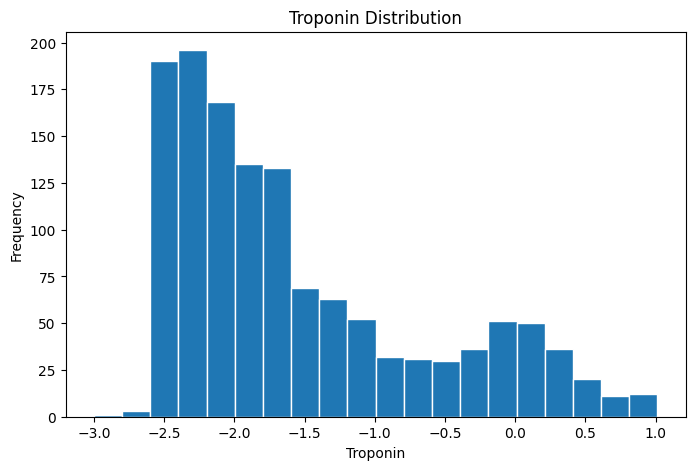

In [172]:
# Visualizing the distribution of troponin levels.

# A logarithmic transformation is applied because troponin values
# may contain extreme differences and strong right skewness.

# This helps improve the readability of the distribution.

plt.figure(figsize=(8,5))

plt.hist(log10(df['troponin']), bins=20, edgecolor='white')

plt.xlabel('Troponin')
plt.ylabel('Frequency')
plt.title('Troponin Distribution')

plt.show()

The histogram shows the distribution of logarithmically transformed troponin levels in the dataset. Most observations are concentrated in the lower troponin ranges, while fewer patients exhibit high troponin values.

The log transformation improves the visualization by reducing the impact of extreme values and making the distribution easier to interpret. Even after the transformation, the distribution still appears moderately skewed, suggesting that elevated troponin levels are less common within the dataset.

Negative values appear because a logarithmic transformation (`log10`) was applied to the troponin feature.

When the original troponin values are between 0 and 1, the logarithm becomes negative:

- `log10(0.1) = -1`
- `log10(0.01) = -2`

This does not mean that troponin levels are negative. It only indicates that some original troponin values are very small.

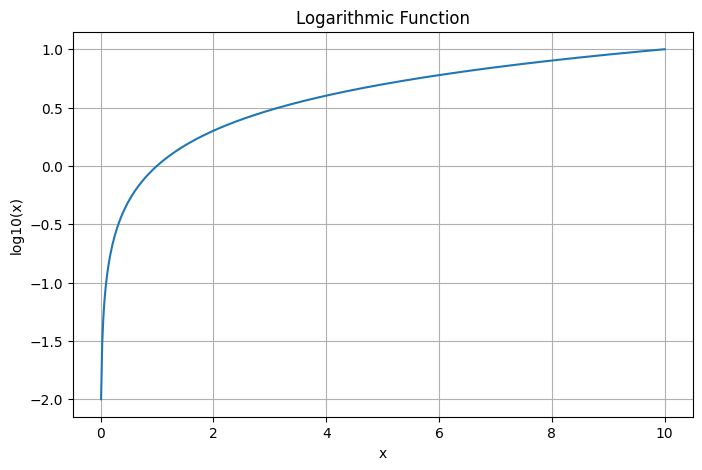

In [173]:
# Plotting the logarithmic function log10(x).

# The graph demonstrates how values between 0 and 1
# produce negative logarithmic outputs.

# Larger values increase slowly due to the logarithmic scale.
x = np.linspace(0.01, 10, 500)

y = np.log10(x)

plt.figure(figsize=(8,5))

plt.plot(x, y)

plt.xlabel('x')
plt.ylabel('log10(x)')
plt.title('Logarithmic Function')

plt.grid(True)

plt.show()

CK-MB (Creatine Kinase-MB) is an enzyme primarily found in heart muscle cells. It belongs to the creatine kinase enzyme family, which plays an important role in energy production within muscles.

When the heart muscle becomes damaged, such as during a heart attack or other cardiovascular conditions, CK-MB is released into the bloodstream. Elevated CK-MB levels may therefore indicate cardiac muscle injury.

CK-MB has historically been used as a biomarker for diagnosing myocardial infarction (heart attack). However, modern medicine more commonly relies on troponin tests because troponin is more specific and sensitive for detecting heart damage.

Despite this, CK-MB can still provide valuable clinical information, especially when combined with other cardiac biomarkers and diagnostic tests.

In [174]:
df['ck_mb'].describe()

count    1319.000000
mean       15.274306
std        46.327083
min         0.321000
25%         1.655000
50%         2.850000
75%         5.805000
max       300.000000
Name: ck_mb, dtype: float64

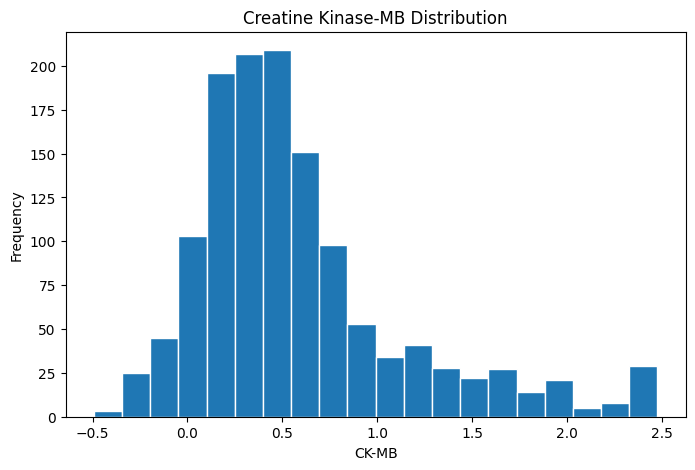

In [175]:
# Visualizing the distribution of troponin levels.

# A logarithmic transformation is applied because troponin values
# may contain extreme differences and strong right skewness.

# This helps improve the readability of the distribution.

plt.figure(figsize=(8,5))

plt.hist(log10(df['ck_mb']), bins=20, edgecolor='white')

plt.xlabel('CK-MB')
plt.ylabel('Frequency')
plt.title('Creatine Kinase-MB Distribution')

plt.show()

Performing a linear regression analysis between troponin and CK-MB levels.

Both variables are important cardiac biomarkers associated with heart muscle damage and cardiovascular disease.

The goal is to investigate whether higher troponin levels are associated with increased CK-MB values.

Applying feature scaling using StandardScaler.

Troponin and CK-MB values may have very different numerical ranges, which can affect regression analysis and visualization.

Standardization transforms the variables so that they have:
- mean ~ 0
- standard deviation ~ 1

This helps place both features on a comparable scale.

In [176]:
scaler = StandardScaler()

In [177]:
scaled_data = scaler.fit_transform(
    df[['troponin', 'ck_mb']]
)

In [178]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=['troponin', 'ck_mb']
)
scaled_df

,troponin,ck_mb
0,-0.302342,-0.290962
1,0.605701,-0.184072
2,-0.310140,-0.286859
3,-0.207032,-0.030324
4,-0.310140,-0.306509
...,...,...
1314,-0.307541,-0.294633
1315,-0.163710,-0.301111
1316,3.369688,-0.303054
1317,-0.001683,-0.204587


In [179]:
scaled_df['troponin'].describe()

count    1.319000e+03
mean     2.020118e-17
std      1.000379e+00
min     -3.118734e-01
25%     -3.075411e-01
50%     -3.006095e-01
75%     -2.386580e-01
max      8.611732e+00
Name: troponin, dtype: float64

In [180]:
scaled_df['ck_mb'].describe()

count    1.319000e+03
mean    -1.077396e-17
std      1.000379e+00
min     -3.228992e-01
25%     -2.940930e-01
50%     -2.682884e-01
75%     -2.044786e-01
max      6.148319e+00
Name: ck_mb, dtype: float64

In [181]:
X = scaled_df[['troponin']]
y = scaled_df['ck_mb']

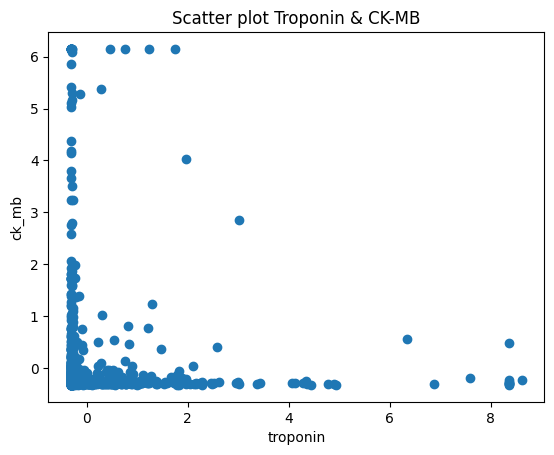

In [182]:
# Visualizing the relationship between troponin and CK-MB levels.
# Each point represents a single patient observation
# The scatter plot helps identify whether higher troponin values
# are associated with increased CK-MB levels.
plt.scatter(X, y)
plt.xlabel('troponin')
plt.ylabel('ck_mb')
plt.title('Scatter plot Troponin & CK-MB')
plt.show()

In [183]:
model = LinearRegression()

In [184]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [185]:
y_pred = model.predict(X)

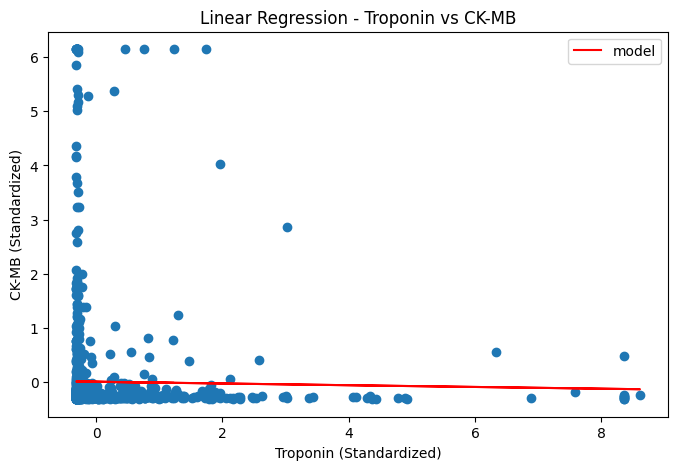

In [186]:
plt.figure(figsize=(8,5))

plt.scatter(scaled_df['troponin'], scaled_df['ck_mb'])

plt.plot(scaled_df['troponin'],y_pred, color='r', label='model')

plt.xlabel('Troponin (Standardized)')
plt.ylabel('CK-MB (Standardized)')
plt.legend()
plt.title('Linear Regression - Troponin vs CK-MB')

plt.show()

In [188]:
print("R2 Score:", r2_score(y, y_pred))

R2 Score: 0.0002562673017774131


The R2 score is extremely close to 0, which indicates that the linear regression model is unable to explain the relationship between troponin and CK-MB levels effectively.

This suggests that there is little to no linear relationship between the two biomarkers within this dataset. In other words, changes in troponin levels do not strongly predict changes in CK-MB values using a simple linear model.